# 01 · DQN con meta fija — la solución principal

**Curso MIA-204 · Trabajo final · Deep RL**

Un agente aprende a navegar terreno real (faldas del Misti, Copernicus DEM GLO-30,
108×108 celdas de 30 m) hasta **una meta fija**, partiendo de **inicios aleatorios**.
Ve solo un parche local 9×9 + un vector a la meta (83 números) y guarda la función Q
en una red neuronal (**DQN**). Baseline exacto: **Dijkstra**.

Todo el código —entorno y algoritmo— vive en archivos `.py` (un solo lugar) y este
notebook lo importa:
- `entorno_drl.py` — el entorno (MDP)
- `dqn.py` — la red `RedQ` y el agente `AgenteDQN` (DQN y Double DQN)
- `train.py` — el bucle de entrenamiento y el test
- `baselines.py` (Dijkstra), `viz.py` (gráficos), `datos.py` (DEM)

Los 3 notebooks (01, 02, 03) comparten estos mismos archivos.

In [1]:
# ── Setup: montar Google Drive e importar el código común ──
import sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA = '/content/drive/Othercomputers/My Mac/dqn'
except ImportError:
    RUTA = '.'   # ejecución local desde la carpeta dqn/
sys.path.insert(0, RUTA)

try:
    import rasterio
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', '-q', 'rasterio'])

import numpy as np, torch
import matplotlib.pyplot as plt
from entorno_drl import TerrenoDRLEnv, NUM_ACCIONES   # el entorno (MDP)
from dqn import RedQ, AgenteDQN                        # la red y el agente DQN
from train import entrenar, evaluar, pares_de_evaluacion, suavizar
from baselines import dijkstra, ruta_greedy, costo_camino, brecha_vs_dijkstra
from datos import ruta_dem
import viz

device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
RUTA_DEM = ruta_dem(RUTA)
print('RUTA del código común:', RUTA)
print('dispositivo:', device, '| DEM:', RUTA_DEM)

Mounted at /content/drive
RUTA del código común: /content/drive/Othercomputers/My Mac/dqn
dispositivo: cuda | DEM: /content/drive/Othercomputers/My Mac/dqn/dem.tif


## 1 · El terreno y lo que ve el agente

El entorno (`entorno_drl.py`): estados = parche local 9×9 + vector a la meta;
acciones = arriba/abajo/izq/der; recompensa = costo por pendiente + bono por acercarse
(shaping), premio al llegar. **Meta fija, inicio aleatorio.**

Mapa 108x108 | meta fija en (np.int64(104), np.int64(104)) | obs = 83 números


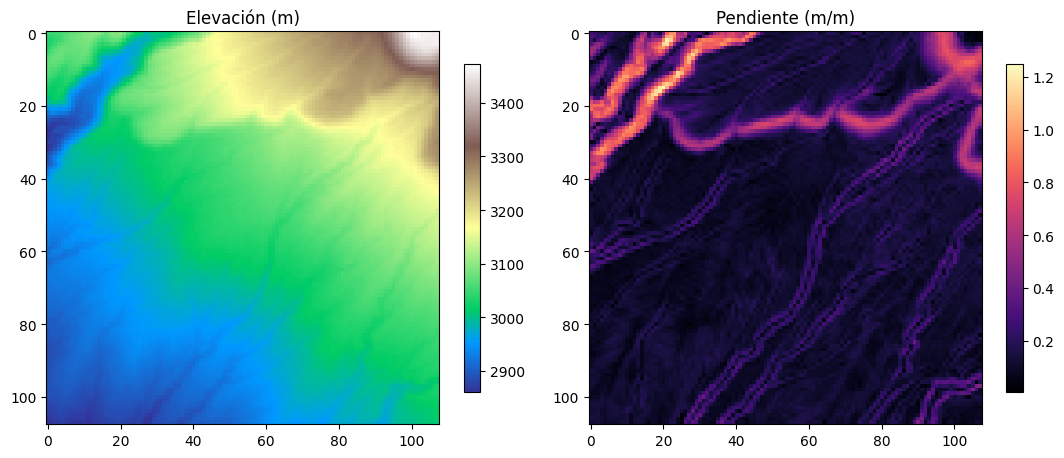

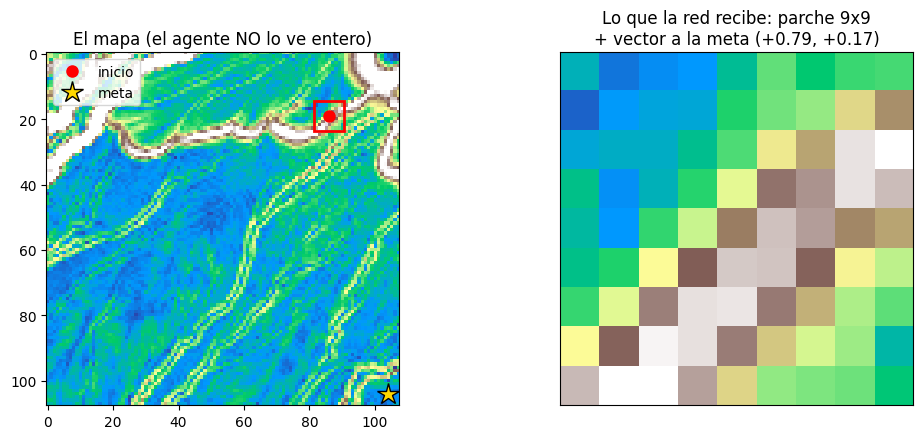

In [2]:
env = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)   # meta_fija=True por defecto
print(f'Mapa {env.filas}x{env.columnas} | meta fija en {env.meta_fija} | '
      f'obs = {env.dim_obs} números')
viz.mapa_terreno(env); plt.show()
viz.que_ve_el_agente(env); plt.show()

## 2 · Entrenar DQN y evaluar

El agente `AgenteDQN` (en `dqn.py`) es la red Q + buffer de reproducción + red objetivo
θ⁻. `entrenar` (en `train.py`) corre los episodios con ε-greedy y curriculum, y cada 100
episodios toma un **test** greedy sobre 20 inicios fijos que nunca se usaron en
entrenamiento — así medimos generalización. Converge ~ep 1400.

In [3]:
EPISODIOS = 1500        # baja a 500 para una prueba rápida
env = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
agente = AgenteDQN(env.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA)
historia = entrenar(env, agente, EPISODIOS)

ep   100 | recompensa    -96.8 | ε 0.77 | test    0% éxito,   500 pasos |    93 s
ep   200 | recompensa    -20.1 | ε 0.59 | test    0% éxito,   500 pasos |   179 s
ep   300 | recompensa      5.0 | ε 0.47 | test   15% éxito,   433 pasos |   234 s
ep   400 | recompensa     -2.2 | ε 0.37 | test   50% éxito,   300 pasos |   282 s
ep   500 | recompensa      0.1 | ε 0.27 | test   80% éxito,   169 pasos |   333 s
ep   600 | recompensa   -156.3 | ε 0.16 | test   85% éxito,   152 pasos |   389 s
ep   700 | recompensa      8.8 | ε 0.06 | test   80% éxito,   173 pasos |   435 s
ep   800 | recompensa     -1.9 | ε 0.05 | test   90% éxito,   134 pasos |   472 s
ep   900 | recompensa      7.7 | ε 0.05 | test   95% éxito,   113 pasos |   517 s
ep  1000 | recompensa      8.0 | ε 0.05 | test  100% éxito,    96 pasos |   563 s
ep  1100 | recompensa      8.8 | ε 0.05 | test  100% éxito,    96 pasos |   598 s
ep  1200 | recompensa     10.0 | ε 0.05 | test   95% éxito,   115 pasos |   636 s
ep  1300 | recom

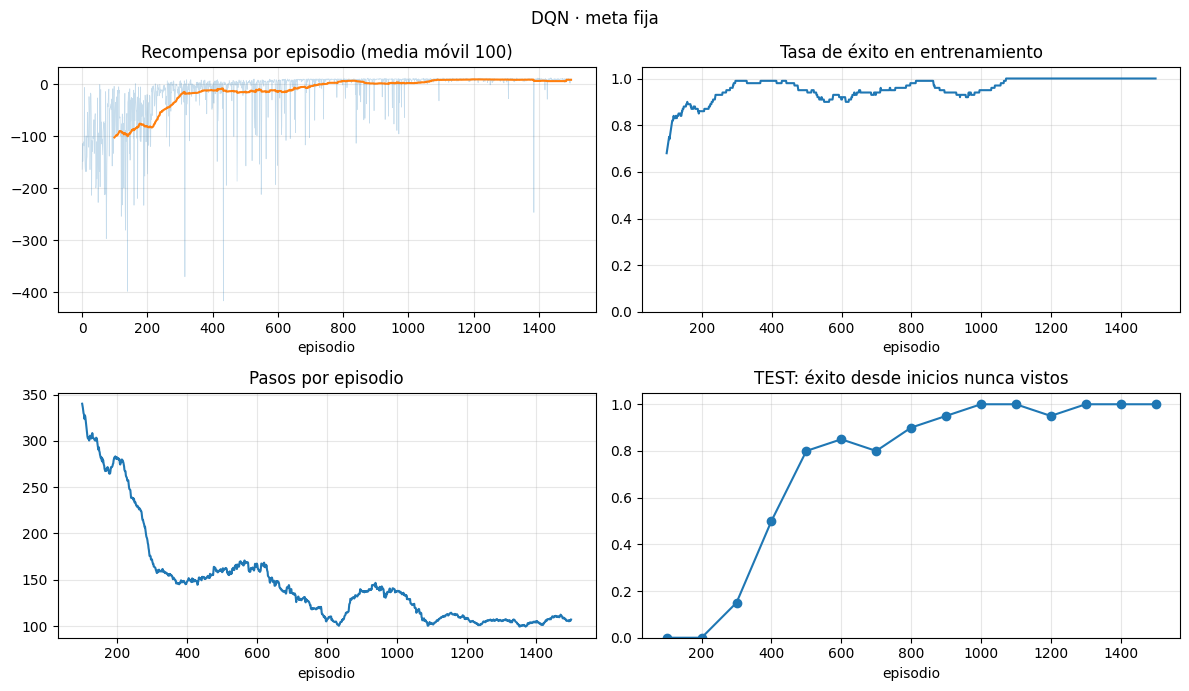

In [4]:
viz.curvas_aprendizaje(historia, 'DQN · meta fija'); plt.show()

## 3 · Rutas aprendidas vs Dijkstra (óptimo exacto)

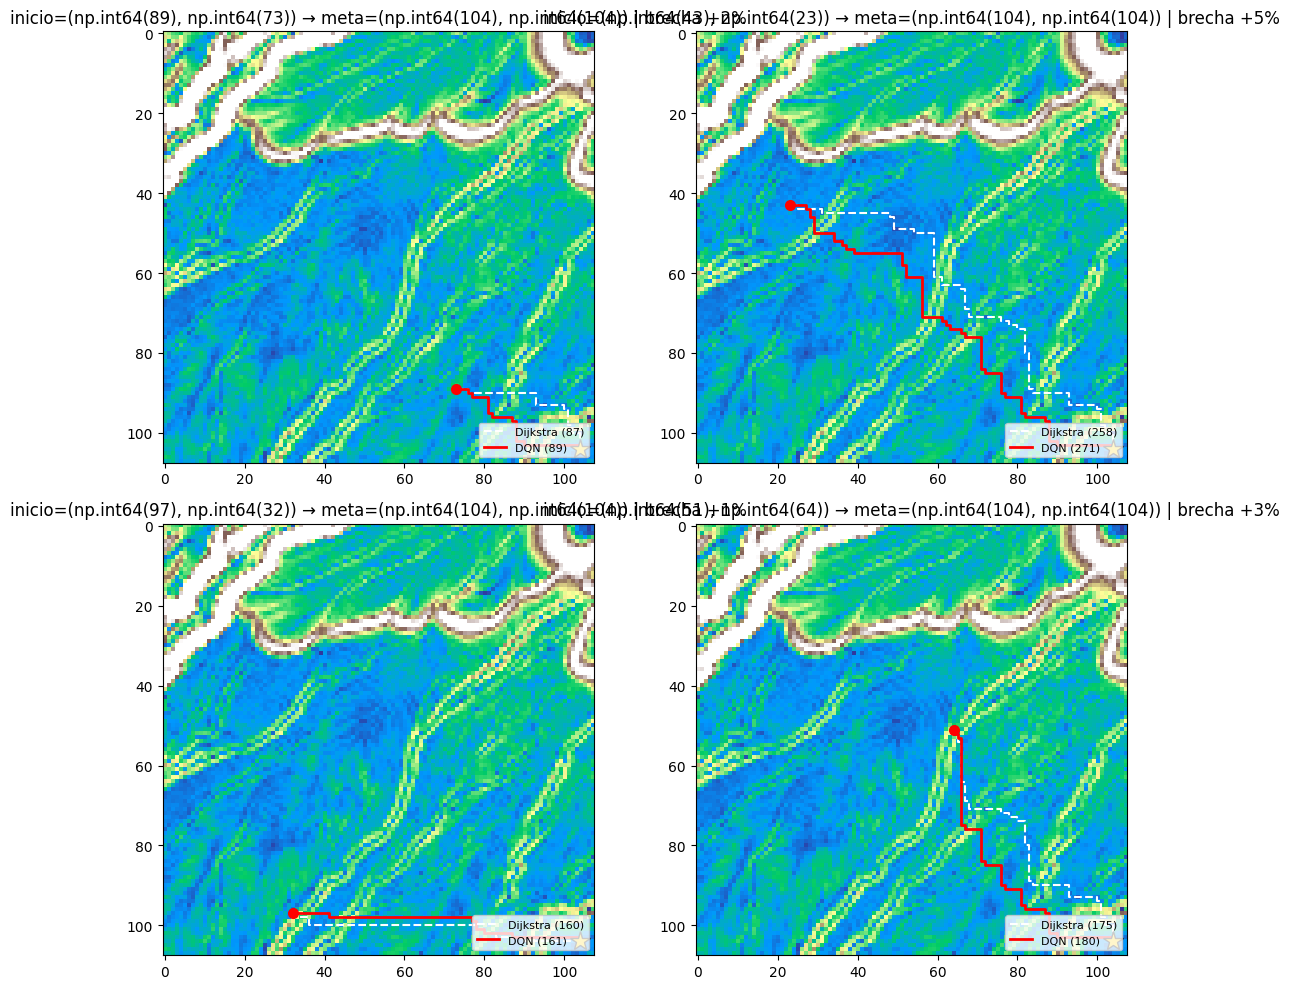

Éxito: 20/20 inicios | brecha media vs óptimo: 3.3%


In [5]:
pares = pares_de_evaluacion(env)
viz.rutas_vs_dijkstra(env, agente, pares, n=4); plt.show()
b, ll, tot = brecha_vs_dijkstra(env, agente, pares)
print(f'Éxito: {ll}/{tot} inicios | brecha media vs óptimo: {b:.1f}%')

## 4 · Ablaciones (ablation study — experimento de Liu & Zou en nuestro terreno)

Apagamos cada mecanismo de DQN y medimos el efecto. Prueba que la Reproducción de
Experiencias (replay) y los Objetivos-Q Fijados (θ⁻) son necesarios, no adornos.
Reutiliza el mismo `AgenteDQN` con banderas distintas. Sube `EPISODIOS_AB` para el
informe.

── DQN completo ──
   test final: 100%
── sin replay ──
   test final: 0%
── sin θ⁻ ──
   test final: 0%
── Double DQN ──
   test final: 100%


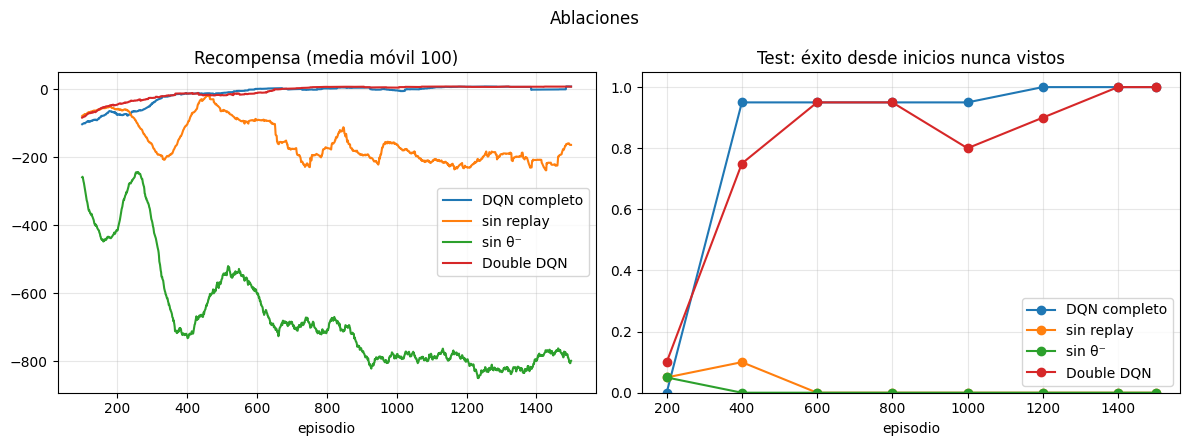

In [6]:
EPISODIOS_AB = 1500
configs = {'DQN completo': dict(), 'sin replay': dict(usar_replay=False),
           'sin θ⁻': dict(usar_target=False), 'Double DQN': dict(doble=True)}
hists, etiquetas = [], []
for nombre, extra in configs.items():
    print(f'── {nombre} ──')
    e = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
    a = AgenteDQN(e.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA, **extra)
    hists.append(entrenar(e, a, EPISODIOS_AB, eval_cada=200, verbose=False))
    etiquetas.append(nombre)
    print(f'   test final: {hists[-1]["eval_exito"][-1]:.0%}')
viz.comparar_curvas(hists, etiquetas, 'Ablaciones'); plt.show()

## 5 · Limitación importante (para el informe)

Nuestra política es **single-goal**: generaliza sobre el punto de inicio pero está
entrenada para una meta fija. Cambiar la meta exige reentrenar. Extenderla a metas
arbitrarias (*goal-conditioned RL*) requiere técnicas más robustas contra la divergencia
que vemos en el notebook 03 — queda como trabajo futuro.